# Electricity Data Exploration

## Objective
This notebook explores the electricity readings in `train.csv` to identify buildings with complete hourly data. The analysis focuses on meter `0`, checks data completeness by building, filters to buildings with a full year of readings, and examines zero-valued readings.

## 1. Load the Data

Import the required libraries and load the training data. The timestamp column is converted to pandas datetime so that its time components can be inspected.

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")
train["timestamp"] = pd.to_datetime(train["timestamp"])

## 2. Inspect the Timestamp and Dataset

The timestamps are checked to confirm the available hourly observations, followed by a basic overview of the dataset.

In [33]:
train.head(10)

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0
5,5,0,2016-01-01,0.0
6,6,0,2016-01-01,0.0
7,7,0,2016-01-01,0.0
8,8,0,2016-01-01,0.0
9,9,0,2016-01-01,0.0


In [34]:
train["timestamp"].dt.hour.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23], dtype=int32)

In [35]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int64         
 1   meter          int64         
 2   timestamp      datetime64[us]
 3   meter_reading  float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 616.9 MB


## 3. Select Electricity Meter Data

The analysis is restricted to `meter = 0`.

In [36]:
train["meter"].value_counts()

train = train[train["meter"] == 0].reset_index(drop=True)
train.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0


In [37]:
train.describe()

,building_id,meter,timestamp,meter_reading
count,1.206091e+07,12060910.0,12060910,1.206091e+07
mean,7.066480e+02,0.0,2016-07-03 03:44:58.224462,1.708256e+02
min,0.000000e+00,0.0,2016-01-01 00:00:00,0.000000e+00
25%,3.450000e+02,0.0,2016-04-04 07:00:00,1.950000e+01
50%,6.980000e+02,0.0,2016-07-03 16:00:00,6.283190e+01
75%,1.063000e+03,0.0,2016-10-02 08:00:00,1.700750e+02
max,1.448000e+03,0.0,2016-12-31 23:00:00,7.976900e+04
std,4.152330e+02,0.0,NaN,3.808343e+02


In [38]:
train.shape

(12060910, 4)

## 4. Check Building Data Completeness

A complete year of hourly observations contains `8,784` readings. Buildings are grouped by the number of available readings and sorted from most complete to least complete.

In [39]:
counts = train.groupby("building_id").size().sort_values(ascending=False)
counts.head(1200)

building_id
1324    8784
1323    8784
31      8784
30      8784
28      8784
        ... 
817     8447
864     8447
836     8447
999     8446
296     8438
Length: 1200, dtype: int64

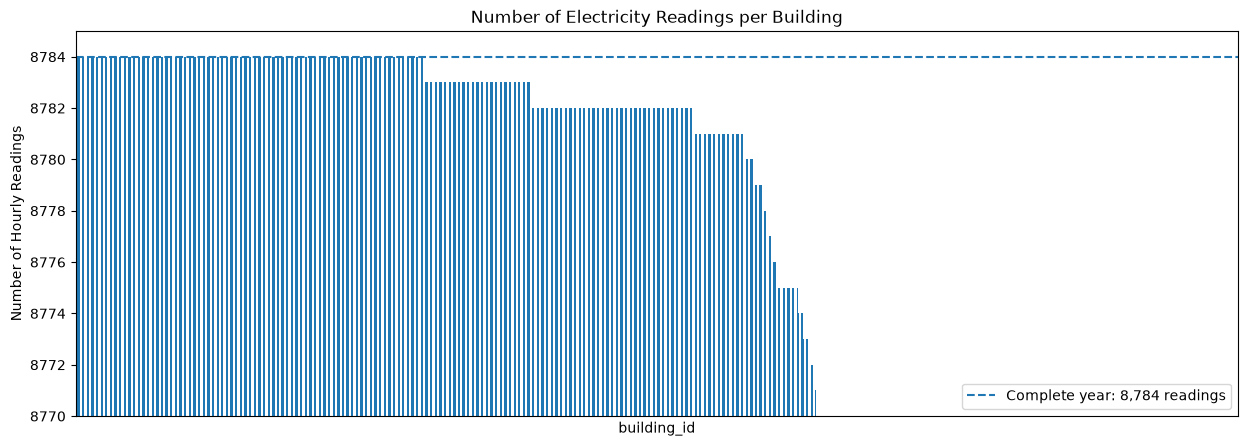

In [40]:
plt.figure(figsize=(15, 5))
counts.plot(kind="bar")
plt.title("Number of Electricity Readings per Building")
plt.ylabel("Number of Hourly Readings")
plt.ylim(8770, 8785)
plt.xticks([])
plt.axhline(8784, linestyle="--", label="Complete year: 8,784 readings")
plt.legend()
plt.show()

In [41]:
complete_count = (counts == 8784).sum()
near_complete_count = (counts >= 8784 * 0.95).sum()

print("Buildings with complete data:", complete_count)
print("Buildings with at least 95% of a full year:", near_complete_count)

Buildings with complete data: 423
Buildings with at least 95% of a full year: 1221


In [42]:
counts.describe()

count    1413.000000
mean     8535.675867
std       757.520255
min       479.000000
25%      8758.000000
50%      8782.000000
75%      8784.000000
max      8784.000000
dtype: float64

## 5. Keep Buildings with Complete Data

Only buildings with exactly `8,784` readings are retained for the next stage of analysis.

In [43]:
complete_buildings = counts[counts == 8784].index
train = train[train["building_id"].isin(complete_buildings)].reset_index(drop=True)

train.describe()

,building_id,meter,timestamp,meter_reading
count,3.715632e+06,3715632.0,3715632,3.715632e+06
mean,6.985343e+02,0.0,2016-07-01 23:29:59.999999,1.569519e+02
min,0.000000e+00,0.0,2016-01-01 00:00:00,0.000000e+00
25%,1.130000e+02,0.0,2016-04-01 11:45:00,1.200000e+01
50%,7.180000e+02,0.0,2016-07-01 23:30:00,5.500000e+01
75%,1.184000e+03,0.0,2016-10-01 11:15:00,1.735890e+02
max,1.324000e+03,0.0,2016-12-31 23:00:00,5.654510e+03
std,4.966161e+02,0.0,NaN,2.790747e+02


## 6. Reshape the Data by Building

The data is pivoted so that each building becomes a column and each timestamp becomes a row. This makes it easier to compare readings across buildings.

In [44]:
building_df = train.pivot(
    index="timestamp",
    columns="building_id",
    values="meter_reading"
)

building_df.head()

building_id,0,1,2,3,4,5,6,7,8,9,...,1313,1314,1315,1316,1317,1319,1320,1321,1323,1324
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,235.53,401.339,35.76,41.2187,373.938,119.9970,89.8141,342.0,177.0,109.0
2016-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,272.71,401.339,34.02,42.2500,373.688,107.9950,89.8240,321.0,180.0,108.0
2016-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,251.74,401.339,32.52,41.1250,372.875,83.9955,81.4715,302.0,177.0,108.0
2016-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,279.55,401.339,32.52,40.4375,372.062,107.9950,107.1200,310.0,167.0,108.0
2016-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,236.37,401.339,32.52,43.0938,368.375,95.9952,70.3711,304.0,138.0,109.0


## 7. Analyse Zero Readings

For each building, calculate the number and percentage of readings equal to zero. Lower zero percentages indicate buildings with fewer zero-valued readings.

In [45]:
zero_counts = (building_df == 0).sum()
zero_percentage = (zero_counts / len(building_df)) * 100

zero_stats = pd.DataFrame({
    "zero_count": zero_counts,
    "zero_percentage": zero_percentage
})

zero_stats = zero_stats.sort_values("zero_percentage")
zero_stats

,zero_count,zero_percentage
building_id,,
1220,0,0.000000
1199,0,0.000000
1198,0,0.000000
1197,0,0.000000
1196,0,0.000000
...,...,...
71,3389,38.581512
69,3627,41.290984
1113,5003,56.955829


## 8. Select Buildings with No Zero Readings

The final subset contains buildings whose electricity readings never equal zero in the available data.

In [46]:
building_df_best = building_df.loc[:, zero_stats["zero_percentage"] == 0]
building_df_best.describe()

building_id,105,107,108,109,110,111,112,113,114,115,...,1196,1197,1198,1199,1201,1205,1211,1216,1217,1220
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.00000,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,78.124031,234.756755,239.155932,255.898231,308.810897,411.954649,26.094731,363.974478,871.00805,490.377471,...,84.732733,228.280665,61.591920,20.287064,87.498162,55.609460,60.879899,23.355676,89.906097,543.478606
std,27.533489,179.950163,51.346955,61.743618,42.148267,65.272680,34.716359,39.459633,142.61732,59.447651,...,25.266562,65.760280,19.588697,3.081857,74.826754,42.930892,29.375965,7.289218,25.947475,355.541173
min,23.303600,0.040500,81.806400,80.930000,86.228300,167.392000,0.007000,159.643000,324.75000,201.543000,...,23.239500,108.663000,13.478000,8.617000,6.864000,13.490000,18.222000,6.968500,28.490500,71.401500
25%,56.299725,60.000000,206.500000,213.101500,295.625000,364.421500,0.007000,334.750000,761.75000,451.375000,...,62.352500,204.749250,46.631750,18.428750,25.525750,23.381750,35.566000,17.870000,66.170750,262.960000
50%,75.115100,323.000000,231.355000,239.328000,310.469000,404.500000,20.253700,359.750000,833.53100,476.329000,...,89.313500,215.943500,59.587500,20.279000,57.435000,31.923000,48.556500,21.652000,86.620500,473.422500
75%,86.464750,388.152000,261.000000,295.173750,338.605000,429.625000,30.598700,377.250000,936.81250,509.830000,...,103.615250,253.838000,75.637000,22.182250,138.868000,85.417500,85.900500,29.191750,113.595500,678.803000
max,173.945000,591.000000,451.500000,553.508000,588.000000,680.250000,174.125000,679.250000,1482.19000,711.375000,...,145.639000,653.661000,123.437000,32.161000,311.129000,189.718000,141.458000,44.405000,158.113000,2402.690000
